# Rojové algoritmy

Na dnešním cvičení se podíváme na další druh přírodou inspirovaných algoritmů, který se používá pro optimalizační úlohy. Budou to takzvané rojové algoritmy, konkrétně algoritmus na optimalizaci pomocí hejna částic (Particle Swarm Optimization - PSO) a optimalizaci mravenčí kolonií (Ant Colony Optimization - ACO). Oba algoritmy jsou relativně jednoduché na implementaci, a proto si je napíšeme sami.

In [1]:
from collections import namedtuple
import math
import functools
import csv
import pprint

import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import collections as mc


## Particle Swarm Optimization

Nejprve se zkusíme podívat na algoritmus optimalizace hejnem částic. Implementace je snadná, protože de facto stačí jenom opsat rovnice.

Algoritmus otestujeme například na problému [Rastrigin funkce](https://en.wikipedia.org/wiki/Rastrigin_function), který jsme řešili na cvičení s evolučními algoritmy (čtvrté cvičení). O této funkci jsme si říkali, že je typickým příkladem nelineární funkce a běžně se používá při testování chování optimalizačních algoritmů. Navíc nalezení jejího minima je složité, protože obsahuje spoustu lokálních minim. Minimum funkce je v počátku soustavy souřadnic - tedy v bodě 0 - s hodnotou 0.

Začneme tím, že si definujeme třídu pro částici, která je definovaná svou pozicí a rychlostí. Vedle toho si pamatuje svou nejlepší pozici v historii. Zároveň definujeme i metodu, aby se jedinec uměl sám vypsat.

In [2]:
class Particle:
    def __init__(self, position, speed):
        self.position = position
        self.speed = speed
        self.best_position = position
            
    def __print__(self):
        return str(self.position) + ", " + str(self.speed) + ", " + str(self.best_position)

Na začátku algoritmu budeme potřebovat umět nainicializovat hejno. To uděláme tak, že každé částici zvolíme náhodnou počáteční pozici a rychlost. Rychlosti se typicky nastavují menší. Dále budeme potřebovat funkci na update všech pozic a rychlostí částic v hejnu. Také bude potřeba funkce na update nejlepšího globálního řešení. Ještě si definujeme fitness funkci, která bude jen hodnota rastrigin funkce v daném bodě. Potom už můžeme definovat hlavní kód algoritmu optimalizace hejnem částic.

In [3]:
pso_rng = np.random.default_rng()

# Random swarm initialization
def init_swarm(size, dimension):
    swarm = [Particle(
        position = pso_rng.uniform(size=(dimension)),
        speed = 0.2 * pso_rng.uniform(size=(dimension)) - 0.1
    ) for _ in range(size)]
    
    return swarm


# Swarm update
def update_swarm(swarm, fitness_function, best_global, phi1=1, phi2=0.5, omega=0.95):
    for particle in swarm:
        particle.speed = \
            omega * particle.speed + \
            phi1 * pso_rng.random() * (particle.best_position - particle.position) + \
            phi2 * pso_rng.random() * (best_global - particle.position)
            
        particle.position = particle.position + particle.speed
        
        if fitness_function(particle.position) < fitness_function(particle.best_position):
            particle.best_position = particle.position

    return swarm


# Find global best
def compute_best_global_position(swarm, fitness_function):
    return min(swarm, key=lambda x: fitness_function(x.best_position)).best_position


# Rastrigin function as our "fitness" function, which we want to minimize
def fitness(position):
    N = len(position)
    A = 10
    value = A * N
    for i in range(len(position)):
        value += (position[i] * position[i]) - A * math.cos(2 * math.pi * position[i])

    return value


# PSO algorithm
def pso(fitness_function, swarm_size, problem_dim, max_iters):
    swarm = init_swarm(size=swarm_size, dimension=problem_dim)
    best_global_position = compute_best_global_position(swarm, fitness_function)
    
    best_fitness = []
    for iteration in range(max_iters):
        # Update
        swarm = update_swarm(swarm, fitness_function, best_global_position)
        best_global_position = compute_best_global_position(swarm, fitness_function)
        
        # Logging
        print(f"Iteration {iteration:4}: {fitness_function(best_global_position):.6f}")
        best_fitness.append(fitness_function(best_global_position))
        
    return best_global_position, best_fitness

Pojďme tedy zkusit náš algoritmus otestovat.

Iteration    0: 3.589633
Iteration    1: 3.335486
Iteration    2: 3.028619
Iteration    3: 3.028619
Iteration    4: 3.028298
Iteration    5: 1.879697
Iteration    6: 1.879697
Iteration    7: 0.396938
Iteration    8: 0.396938
Iteration    9: 0.396938
Iteration   10: 0.211616
Iteration   11: 0.211616
Iteration   12: 0.166119
Iteration   13: 0.092680
Iteration   14: 0.092680
Iteration   15: 0.063618
Iteration   16: 0.063618
Iteration   17: 0.042955
Iteration   18: 0.042955
Iteration   19: 0.042955
Iteration   20: 0.042955
Iteration   21: 0.018630
Iteration   22: 0.018630
Iteration   23: 0.008925
Iteration   24: 0.008925
Iteration   25: 0.007996
Iteration   26: 0.006111
Iteration   27: 0.006111
Iteration   28: 0.006111
Iteration   29: 0.005520
Iteration   30: 0.005520
Iteration   31: 0.001127
Iteration   32: 0.001127
Iteration   33: 0.000681
Iteration   34: 0.000681
Iteration   35: 0.000390
Iteration   36: 0.000390
Iteration   37: 0.000390
Iteration   38: 0.000390
Iteration   39: 0.000327


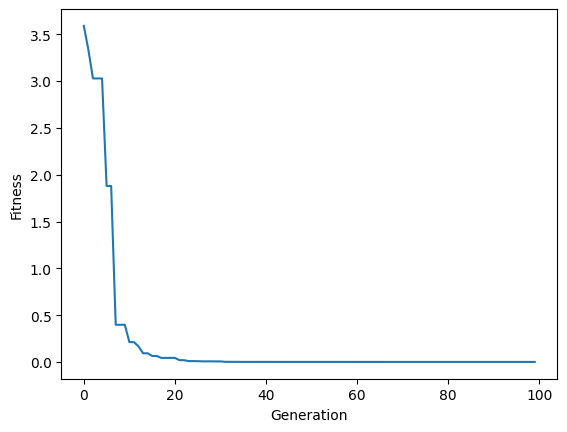

In [4]:
best_position, best_length = pso(fitness, swarm_size=1000, problem_dim=4, max_iters=100)

print("\nBest value and position:", fitness(best_position), "at position", best_position)

plt.plot(best_length)
plt.ylabel("Fitness")
plt.xlabel("Generation")
plt.show()

Zde si můžeme zkusit měnit dimenzi problému a pozorovat, že pro rostoucí dimenzi je třeba zvětšovat velikost hejna, aby se algoritmus nezasekl v lokálním optimu a že na počtu generací to až zas tolik nezáleží, protože algoritmus brzy zkonverguje do nějakého optima a tam už zůstane.


## Ant Colony Optimization

Optimalizace mravenčí kolonií (Ant Colony Optimization (ACO)) se hodí především pro kombinatorickou optimalizaci, konkrétně na problémy, které se dají převést na hledání cest v grafu. Zkusíme si s jeho pomocí vyřešit problém obchodního cestujícího, který se dá převést na problém hledání nejkratší Hamiltonovské kružnice v úplném grafu. Implementace už je trochu složitější, ale pořád celkem rozumná.

Než se do toho ale pustíme, tak pro zajímavost a ilustraci toho, co je vlastně inspirací tohoto algoritmu: Rozhraní pro modelování různých přírodou inspirovaných systémů a algoritmů [NetLogo](http://ccl.northwestern.edu/netlogo/) poskytuje i simulaci mravenců při hledání potravy. Podívat se na ni můžeme [zde](http://www.netlogoweb.org/launch#http://www.netlogoweb.org/assets/modelslib/Sample%20Models/Biology/Ants.nlogo).

Nejprve si vytvoříme kolekci `namedtuple`, do které si uložíme informace o vrcholu, tedy jeho souřadnice a název. Je vhodnější než normální třída, protože je to rychlejší struktura. Dále budeme potřebovat funkci, co nám spočítá vzdálenost dvou bodů. To uděláme chytře a použijeme k tomu LRU (Least Recently Used) cache, která si pamatuje vyhodnocené funkce a při jejich opakovaném volání se stejnými parametry se nemusí znovu vyhodnocovat. Dále se bude hodit fitness funkce, která jen vyhodnotí danou cestu mezi městy tak, že bere dvojice po sobě jdoucích vrcholů v řešení a sčítá vzdálenosti měst.

In [5]:
Vertex = namedtuple("Vertex", ["name", "x", "y"])


@functools.lru_cache(maxsize=None)
def distance_function(v1, v2):
    return math.sqrt(((v1.x - v2.x) * (v1.x - v2.x)) + ((v1.y - v2.y) * (v1.y - v2.y)))


def solution_length(solution, vertices, distance_function):
    solution_distance = 0
    for x, y in zip(solution, solution[1:] + solution[0:1]):
        solution_distance += distance_function(vertices[x], vertices[y])
    
    return solution_distance


Samotný algoritmus bude ještě potřebovat funkci na počáteční inicializaci feromonu, kde sice na začátku by z logiky věci měla být stopa všude nulová, ale protože s ní pracujeme jako s pravděpodobností, tak by to nefungovalo. Tak ji prostě nastavíme na nějakou malou hodnotu. Také bude potřeba dělat update feromonu a to tak, že na všechny hrany v cestě rozpočítáme rovnoměrně fitness, která říká, jak byla cesta dobrá. A protože délku chceme minimalizovat, tak použijeme inverz fitness, tedy *Q / fitness_value*, kde *Q* bude nějaká konstanta. Nesmíme zapomenout během updatu ani na vypařování feromonu.

In [6]:
def initialize_pheromone(N):
    return 0.01 * np.ones(shape=(N,N))


def update_pheromone(pheromones_array, solutions, solution_lengths, Q, rho):
    pheromone_update = np.zeros(shape=pheromones_array.shape)
    for solution, solution_length in zip(solutions, solution_lengths):
        for x, y in zip(solution, solution[1:] + solution[0:1]):
            pheromone_update[x, y] += Q / solution_length
    
    return (1 - rho) * pheromones_array + pheromone_update


Ještě nám zbývá pomocná funkce, kde mravenec generuje řešení, tedy náhodně prochází města, dokud neobejde všechna. Tu napíšeme jako generátor, který postupně nageneruje řešení pro všechny mravence.

In [ ]:
aco_rng = np.random.default_rng()

def generate_solutions(vertices, pheromones, distance_function, number_of_ants, alpha, beta):
    
    # Probability of selecting v2 right after v1
    def compute_prob(v1, v2):
        inverse_distance = 1 / distance_function(vertices[v1], vertices[v2])
        tau = pheromones[v1, v2]
        ret = pow(tau, alpha) * pow(inverse_distance, beta)
        return ret if ret > 1e-12 else 1e-12

    number_of_vertices = len(vertices)
    for _ in range(number_of_ants):
        available = list(range(number_of_vertices))
        solution = [aco_rng.integers(0, number_of_vertices)]
        available.remove(solution[0])
        
        while available:
            probs = np.array(list(map(lambda x: compute_prob(solution[-1], x), available)))
            selected = aco_rng.choice(available, p=(probs / np.sum(probs))) # Edge selection
            solution.append(selected)
            available.remove(selected)
            
        yield solution

 Pak už můžeme napsat hlavní funkci algoritmu, kde se vytváří řešení a podle jejich kvality se upravuje feromon na hranách. Zároveň si pamatujeme nejlepší řešení, abychom ho na konci mohli vrátit.

In [12]:
# Main ACO code
def ant_solver(vertices, distance_function, number_of_ants=100, max_iterations=100, alpha=1, beta=3, Q=10, rho=0.5):
    pheromones = initialize_pheromone(len(vertices))
    best_solution = None
    best_length = float("inf")
    log_of_best_distances = list()
    
    print("Iteration\tMinimum value\tMean value\tMaximum value")
    
    for i in range(max_iterations):
        candidate_solutions = list(generate_solutions(vertices, pheromones, distance_function, number_of_ants, alpha=alpha, beta=beta))
        solution_lengths = list(map(lambda x: solution_length(x, vertices, distance_function), candidate_solutions))
        pheromones = update_pheromone(pheromones, candidate_solutions, solution_lengths, Q=Q, rho=rho)
        
        for candidate_solution, candidate_length in zip(candidate_solutions, solution_lengths):
            if candidate_length < best_length:
                best_length = candidate_length
                best_solution = candidate_solution
                
        log_of_best_distances.append(np.min(solution_lengths))
        
        print(f"{i:8}:\t{np.min(solution_lengths):5.8f}\t{np.mean(solution_lengths):5.8f}\t{np.max(solution_lengths):5.8f}")
        
    return best_solution, pheromones, log_of_best_distances

Zkusíme si nyní algoritmus otestovat na hlavních evropských městech, vstupní data jsou uložena v souboru *cities.csv*.

In [9]:
vertices = []
with open("cities.csv") as cities_file:
    csv_reader = csv.reader(cities_file, delimiter=',')
    for row in csv_reader:
        vertices.append(Vertex(row[0], float(row[2]), float(row[1])))

pprint.pprint(vertices)

[Vertex(name='Tirana', x=19.81666667, y=41.31666667),
 Vertex(name='Andorra la Vella', x=1.5, y=42.5),
 Vertex(name='Vienna', x=16.36666667, y=48.21666667),
 Vertex(name='Minsk', x=27.55, y=53.9),
 Vertex(name='Brussels', x=4.316666667, y=50.81666667),
 Vertex(name='Sarajevo', x=18.36666667, y=43.85),
 Vertex(name='Sofia', x=23.3, y=42.68333333),
 Vertex(name='Zagreb', x=15.96666667, y=45.8),
 Vertex(name='Nicosia', x=33.36666667, y=35.15),
 Vertex(name='Prague', x=14.41666667, y=50.06666667),
 Vertex(name='Copenhagen', x=12.56666667, y=55.66666667),
 Vertex(name='Tallinn', x=24.73333333, y=59.43333333),
 Vertex(name='Helsinki', x=24.93333333, y=60.16666667),
 Vertex(name='Paris', x=2.333333333, y=48.85),
 Vertex(name='Berlin', x=13.36666667, y=52.51666667),
 Vertex(name='Athens', x=23.71666667, y=37.96666667),
 Vertex(name='Budapest', x=19.06666667, y=47.5),
 Vertex(name='Reykjavik', x=-21.91666667, y=64.13333333),
 Vertex(name='Dublin', x=-6.25, y=53.31666667),
 Vertex(name='Rome', x

Iteration	Minimum value	Mean value	Maximum value
       0:	451.83803955	562.31866820	667.96800918
       1:	360.16676945	449.89765289	562.58153301
       2:	323.13490819	401.46127323	477.39101983
       3:	308.06491643	381.20525070	458.26678529
       4:	266.49015113	362.33027455	431.29630042
       5:	260.11293240	354.60502105	417.11365730
       6:	273.29179874	341.10898528	430.55790984
       7:	265.60215541	335.79308931	413.50852534
       8:	263.27279460	333.10591973	426.61951069
       9:	273.05094818	325.30074591	417.99765413
      10:	262.65317691	321.51390364	395.35463237
      11:	263.87818753	323.84453483	421.81829155
      12:	247.40069145	314.99201816	381.05417142
      13:	256.93267614	313.29192867	397.51548978
      14:	248.99650744	315.62669998	376.67056225
      15:	260.16304857	317.50550508	393.90828079
      16:	255.62583484	310.12453003	410.06218379
      17:	260.05824655	310.74718278	371.57833639
      18:	245.33441388	310.54057951	397.48744753
      19:	257.199089

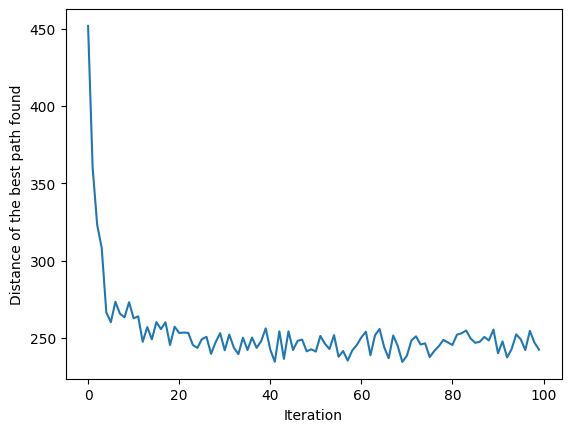

In [13]:
best_solution, pheromones, log_of_best_distances = ant_solver(vertices, distance_function)

plt.plot(log_of_best_distances)
plt.ylabel("Distance of the best path found")
plt.xlabel("Iteration")
plt.show()

Jak můžeme vidět v grafu výše, podobně jako v případě PSO nedává nutně smysl v této základní verzi algoritmu používat příliš velké množství iterací. Lepších výsledků už pravděpodobně dosáhneme opakovaným spoštěním kratších běhů nebo větší populací pro plnou utilizaci informace uložené ve feromonech v každém kroku.

Nakonec si tedy vykreslíme nalezené řešení a množství feromononu na jednotlivých hranách. Feromon bude modrý, tloušťka čáry značí množství feromonu na hraně. Odkomentováním zakomentované řádky si můžete vyzkoušet, jak různé nastavení alpha a beta ovlivňuje nalezená řešení.

Solution length:  234.3951388585336


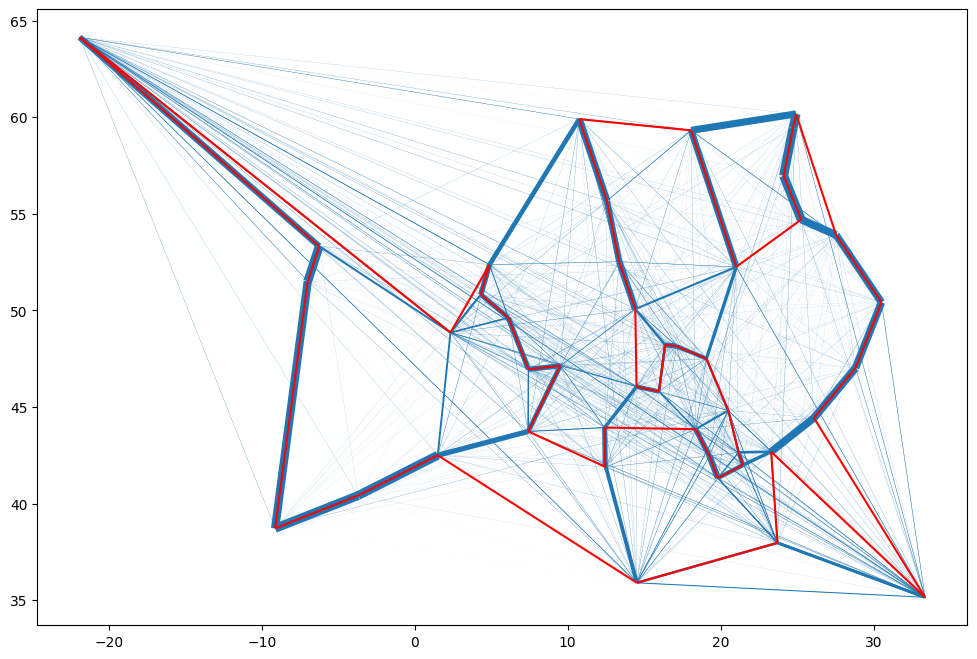

[Vertex(name='Amsterdam', x=4.883333333, y=52.36666667),
 Vertex(name='Brussels', x=4.316666667, y=50.81666667),
 Vertex(name='Luxemburg', x=6.116666667, y=49.61666667),
 Vertex(name='Bern', x=7.433333333, y=46.95),
 Vertex(name='Vaduz', x=9.516666667, y=47.13333333),
 Vertex(name='Monaco', x=7.416666667, y=43.73333333),
 Vertex(name='Rome', x=12.5, y=41.88333333),
 Vertex(name='Vatican City', x=12.45, y=41.9),
 Vertex(name='San Marino', x=12.41666667, y=43.93333333),
 Vertex(name='Sarajevo', x=18.36666667, y=43.85),
 Vertex(name='Podgorica', x=19.26666667, y=42.46666667),
 Vertex(name='Tirana', x=19.81666667, y=41.31666667),
 Vertex(name='Skopje', x=21.46666667, y=42.0),
 Vertex(name='Pristina', x=21.16666667, y=42.65),
 Vertex(name='Belgrade', x=20.5, y=44.81666667),
 Vertex(name='Budapest', x=19.06666667, y=47.5),
 Vertex(name='Bratislava', x=17.11666667, y=48.15),
 Vertex(name='Vienna', x=16.36666667, y=48.21666667),
 Vertex(name='Zagreb', x=15.96666667, y=45.8),
 Vertex(name='Ljub

In [14]:
# Render pheromones (blue, line width corresponds to the pheromon value on the edge)
lines = []
colors = []
for i, v1 in enumerate(vertices):
    for j, v2 in enumerate(vertices):
        lines.append([(v1.x, v1.y), (v2.x, v2.y)])
        colors.append(pheromones[i, j])

lc = mc.LineCollection(lines, linewidths=np.array(colors))

plt.figure(figsize=(12, 8))
ax = plt.gca()
ax.add_collection(lc)
ax.autoscale()

solution = best_solution

# Here, you can test the influence of the individual parameters on the generated candidate solution
# solution = list(generate_solutions(vertices, pheromones, distance_function, number_of_ants=1, alpha=3, beta=1))[0]

# Print solution's length
print("Solution length: ", solution_length(solution, vertices, distance_function))

# Render the solution (red)
solution_lines = []
for i, j in zip(solution, solution[1:] + solution[0:1]):
    solution_lines.append([(vertices[i].x, vertices[i].y), (vertices[j].x, vertices[j].y)])

solutions_lc = mc.LineCollection(solution_lines, colors="red")

ax.add_collection(solutions_lc)

plt.show()

# Print towns in the order of the solution
solution_vertices = [vertices[i] for i in solution]
pprint.pprint(solution_vertices)

## Úkol na cvičení

Pohrejte si s PSO, ať vidíte, jak dimenze problému ovlivňují potřebný počet částic, a zároveň ať si empiricky ověříte, že algoritmu stačí nemnoho iterací, více že mu stejně většinou příliš nepomůže. (Můžete samozřejmě funkci i upravit a hrát si i s hyperparametry.)

Vyzkoušejte si chování ACO v závislosti na různém nastavení hyperparametrů. Všimněte si, že $\alpha$ a $\beta$ jsou svým způsobem provázané hyperparametry, neboť v podstatě odpovídají váhám (multiplikativní) kombinace feromonů a heuristické funkce. Dále $\alpha$ (a tranzitivně tak i $\beta$) je závislé na hodnotě hyperparametrů *Q* a $\rho$, neboť ty mi určují, kolik tak zhruba budu mít feromonů na každé hraně v každé iteraci. Nakonec pak *Q* (a potažmo i $\alpha$) je závislé na hodnotách "fitness" funkce, která mi dává kvalitu každého řešení, protože by mi hodnota *Q* měla nějakým způsobem vyvažovat magnitudu této funkce. Navíc je *Q* závislé i na počtu mravenců, neboť ten mi určuje kolikrát maximálně položíme v jedné iteraci na jednu hranu nějaký feromon. Vymysleli byste nějaká vylepšení k našemu kódu, která by koncepčně mohla pomoct s naší úlohou? (Například update feromonů by dávalo smysl trochu upravit. Dává v našem zadání smysl uvažovat orientovaný, nebo neorientovaný graf?)

## Domácí úkol - Vehicle routing problem

Za domácí úkol budete mít vyřešit Vehicle routing problem pomocí ACO. Jedná se v podstatě o zobecnění problému obchodního cestujícího, kde cílem je optimalizovat dodání zásilek jejich adresátům za pomoci několika vozů.

[Detailní zadání](https://kam.mff.cuni.cz/~lorenc/teach/PIA_hw/homeworks-routing.html) je možno najít na stránkách cvičení.